# Online Retail Dataset(UCI) 기반 PyTorch 연관분석 실습

이 노트북은 UCI Machine Learning Repository의 **Online Retail Dataset**을 인터넷에서 직접 다운로드한 뒤, `PyTorch` 텐서 연산을 활용하여 연관규칙 분석을 수행하는 실습 예제입니다.

## 실습 목표

1. UCI Online Retail 데이터를 인터넷에서 다운로드한다.
2. 거래 데이터에서 취소 거래, 수량 오류, 가격 오류, 결측값을 제거한다.
3. InvoiceNo 단위로 장바구니 거래 데이터를 만든다.
4. 상품 출현 여부를 0/1 One-Hot Matrix로 변환한다.
5. PyTorch 텐서로 Support, Confidence, Lift를 계산한다.
6. 최소 지지도와 최소 신뢰도 기준으로 연관규칙을 생성한다.
7. 추천 상품 함수를 작성한다.
8. 상위 상품과 상위 규칙을 시각화한다.

> 참고: Online Retail 데이터는 약 54만 행 규모입니다. 연관규칙 분석은 상품 조합 수가 빠르게 증가하므로, 실습에서는 상위 빈도 상품 일부만 사용하도록 구성했습니다.

In [1]:
# ============================================================
# 1. Colab 실행 환경 준비
# ============================================================

# openpyxl은 pandas가 Excel(.xlsx) 파일을 읽을 때 사용하는 엔진입니다.
# Colab에는 설치되어 있는 경우가 많지만, 설치되지 않은 환경에서도 실행되도록 명시적으로 설치합니다.
!pip -q install openpyxl

In [2]:
# ============================================================
# 2. 필요한 라이브러리 불러오기
# ============================================================

# os는 파일 경로 존재 여부 확인, 폴더 생성 등 운영체제 관련 작업에 사용합니다.
import os

# zipfile은 UCI에서 내려받은 zip 압축 파일을 해제하는 데 사용합니다.
import zipfile

# urllib.request는 인터넷 URL에서 파일을 다운로드할 때 사용합니다.
import urllib.request

# itertools.combinations는 상품 조합을 만들 때 사용합니다.
from itertools import combinations

# numpy는 수치 계산과 배열 처리를 위해 사용합니다.
import numpy as np

# pandas는 표 형태 데이터프레임 처리에 사용합니다.
import pandas as pd

# torch는 PyTorch 텐서 연산을 수행하기 위해 사용합니다.
import torch

# matplotlib.pyplot은 그래프 시각화에 사용합니다.
import matplotlib.pyplot as plt

# warnings는 불필요한 경고 메시지를 숨기기 위해 사용합니다.
import warnings

# 경고 메시지가 너무 많이 출력되지 않도록 설정합니다.
warnings.filterwarnings("ignore")

# 실행 결과가 재현되도록 PyTorch 난수 시드를 고정합니다.
torch.manual_seed(42)

# numpy 기반 난수도 재현 가능하도록 시드를 고정합니다.
np.random.seed(42)

In [3]:
# ============================================================
# 3. UCI Online Retail Dataset 다운로드
# ============================================================

# UCI Machine Learning Repository의 Online Retail Dataset 압축 파일 URL입니다.
# 이 URL은 UCI의 public static dataset 저장소를 가리킵니다.
uci_zip_url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

# 다운로드한 zip 파일을 저장할 파일명입니다.
zip_path = "online_retail.zip"

# 압축을 해제할 폴더명입니다.
extract_dir = "online_retail_data"

# 실제 Excel 데이터 파일명입니다.
xlsx_path = os.path.join(extract_dir, "Online Retail.xlsx")

# 압축 해제 폴더가 없으면 새로 생성합니다.
os.makedirs(extract_dir, exist_ok=True)

# Excel 파일이 이미 존재하지 않을 때만 다운로드를 수행합니다.
if not os.path.exists(xlsx_path):

    # UCI 서버에서 zip 파일을 다운로드합니다.
    urllib.request.urlretrieve(uci_zip_url, zip_path)

    # 다운로드한 zip 파일을 읽기 모드로 엽니다.
    with zipfile.ZipFile(zip_path, "r") as zip_ref:

        # zip 파일 안의 모든 파일을 extract_dir 폴더로 압축 해제합니다.
        zip_ref.extractall(extract_dir)

# 데이터 파일 경로를 출력하여 정상적으로 준비되었는지 확인합니다.
print("데이터 파일 경로:", xlsx_path)

# 파일 존재 여부를 출력합니다.
print("파일 존재 여부:", os.path.exists(xlsx_path))

데이터 파일 경로: online_retail_data/Online Retail.xlsx
파일 존재 여부: True


In [4]:
# ============================================================
# 4. Excel 데이터 읽기
# ============================================================

# pandas의 read_excel() 함수로 Online Retail Excel 파일을 읽습니다.
# 이 데이터는 InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country 컬럼을 포함합니다.
df = pd.read_excel(xlsx_path)

# 데이터의 앞쪽 5행을 출력하여 구조를 확인합니다.
display(df.head())

# 데이터의 행과 열 개수를 출력합니다.
print("원본 데이터 크기:", df.shape)

# 각 컬럼의 자료형과 결측치 개수를 확인합니다.
df.info()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


원본 데이터 크기: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
# ============================================================
# 5. 데이터 전처리
# ============================================================

# 원본 데이터를 직접 수정하지 않기 위해 복사본을 생성합니다.
data = df.copy()

# InvoiceNo를 문자열로 변환합니다.
# 취소 거래는 InvoiceNo가 'C'로 시작하는 경우가 있으므로 문자열 처리가 필요합니다.
data["InvoiceNo"] = data["InvoiceNo"].astype(str)

# 상품명 Description의 앞뒤 공백을 제거합니다.
# 같은 상품인데 공백 차이로 다른 상품으로 인식되는 문제를 줄이기 위한 처리입니다.
data["Description"] = data["Description"].astype(str).str.strip()

# 취소 거래를 제거합니다.
# InvoiceNo가 C로 시작하면 고객이 구매를 취소한 거래로 해석할 수 있습니다.
data = data[~data["InvoiceNo"].str.startswith("C")]

# 수량이 0 이하인 행을 제거합니다.
# Quantity가 0 또는 음수이면 정상 구매 수량으로 보기 어렵습니다.
data = data[data["Quantity"] > 0]

# 단가가 0 이하인 행을 제거합니다.
# UnitPrice가 0 또는 음수이면 정상 판매 데이터로 보기 어렵습니다.
data = data[data["UnitPrice"] > 0]

# 상품명 결측 또는 비정상 문자열을 제거합니다.
# Description이 비어 있거나 nan 문자열이면 분석 대상에서 제외합니다.
data = data[data["Description"].notna()]
data = data[data["Description"].str.lower() != "nan"]
data = data[data["Description"].str.len() > 0]

# 분석 편의를 위해 InvoiceNo와 Description 컬럼만 사용합니다.
basket_source = data[["InvoiceNo", "Description"]].copy()

# 전처리 후 데이터 크기를 출력합니다.
print("전처리 후 데이터 크기:", basket_source.shape)

# 거래 수를 확인합니다.
print("거래 수:", basket_source["InvoiceNo"].nunique())

# 상품 수를 확인합니다.
print("상품 수:", basket_source["Description"].nunique())

# 전처리 후 데이터 일부를 확인합니다.
display(basket_source.head())

전처리 후 데이터 크기: (530104, 2)
거래 수: 19960
상품 수: 4015


,InvoiceNo,Description
0,536365,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,WHITE METAL LANTERN
2,536365,CREAM CUPID HEARTS COAT HANGER
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,RED WOOLLY HOTTIE WHITE HEART.


In [6]:
# ============================================================
# 6. 거래 단위 장바구니 데이터 생성
# ============================================================

# InvoiceNo별로 상품명을 리스트로 묶습니다.
# 하나의 InvoiceNo는 하나의 장바구니 거래를 의미합니다.
transactions = (
    basket_source
    .groupby("InvoiceNo")["Description"]
    .apply(lambda x: sorted(set(x)))
    .tolist()
)

# 전체 거래 수를 출력합니다.
print("전체 거래 수:", len(transactions))

# 앞쪽 3개 거래를 출력하여 장바구니 구조를 확인합니다.
for i, transaction in enumerate(transactions[:3]):

    # 각 거래 번호와 거래에 포함된 상품 일부를 출력합니다.
    print(f"거래 {i+1}:", transaction[:10])

전체 거래 수: 19960
거래 1: ['CREAM CUPID HEARTS COAT HANGER', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN']
거래 2: ['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK']
거래 3: ['ASSORTED COLOUR BIRD ORNAMENT', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE ALPHABET BLOCKS', 'BOX OF VINTAGE JIGSAW BLOCKS', 'DOORMAT NEW ENGLAND', 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'HOME BUILDING BLOCK WORD', 'IVORY KNITTED MUG COSY', 'LOVE BUILDING BLOCK WORD', "POPPY'S PLAYHOUSE BEDROOM"]


In [7]:
# ============================================================
# 7. 실습 속도 조절을 위한 상위 상품 선택
# ============================================================

# 모든 상품을 사용하면 상품 조합 수가 매우 많아져 Colab에서 실행 시간이 길어질 수 있습니다.
# 따라서 실습에서는 거래 빈도가 높은 상위 상품만 선택합니다.
TOP_N_ITEMS = 60

# 전체 거래에서 각 상품이 몇 개의 거래에 등장했는지 계산하기 위한 딕셔너리입니다.
item_count = {}

# 모든 거래를 하나씩 반복합니다.
for transaction in transactions:

    # 하나의 거래 안에서 중복 상품은 제거한 뒤 반복합니다.
    for item in set(transaction):

        # 딕셔너리에 상품이 없으면 0으로 시작하고, 있으면 기존 값에 1을 더합니다.
        item_count[item] = item_count.get(item, 0) + 1

# 상품별 거래 등장 횟수를 데이터프레임으로 변환합니다.
item_freq_df = pd.DataFrame(
    [{"item": item, "count": count} for item, count in item_count.items()]
)

# 전체 거래 수로 나누어 각 상품의 지지도를 계산합니다.
item_freq_df["support"] = item_freq_df["count"] / len(transactions)

# 등장 횟수가 많은 상품 순서로 정렬합니다.
item_freq_df = item_freq_df.sort_values("count", ascending=False).reset_index(drop=True)

# 상위 TOP_N_ITEMS개 상품만 선택합니다.
top_items = item_freq_df.head(TOP_N_ITEMS)["item"].tolist()

# 선택된 상품 수를 출력합니다.
print("실습에 사용할 상위 상품 수:", len(top_items))

# 상위 10개 상품을 확인합니다.
display(item_freq_df.head(10))

실습에 사용할 상위 상품 수: 60


,item,count,support
0,WHITE HANGING HEART T-LIGHT HOLDER,2256,0.113026
1,JUMBO BAG RED RETROSPOT,2089,0.104659
2,REGENCY CAKESTAND 3 TIER,1988,0.099599
3,PARTY BUNTING,1685,0.084419
4,LUNCH BAG RED RETROSPOT,1564,0.078357
5,ASSORTED COLOUR BIRD ORNAMENT,1455,0.072896
6,SET OF 3 CAKE TINS PANTRY DESIGN,1385,0.069389
7,PACK OF 72 RETROSPOT CAKE CASES,1320,0.066132
8,LUNCH BAG BLACK SKULL.,1273,0.063778
9,NATURAL SLATE HEART CHALKBOARD,1249,0.062575


In [8]:
# ============================================================
# 8. One-Hot Encoding 거래-상품 행렬 생성
# ============================================================

# 상품명을 열 번호로 변환하기 위한 딕셔너리입니다.
item_to_idx = {item: idx for idx, item in enumerate(top_items)}

# 열 번호를 다시 상품명으로 변환하기 위한 딕셔너리입니다.
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

# 거래 수를 저장합니다.
num_transactions = len(transactions)

# 상품 수를 저장합니다.
num_items = len(top_items)

# 거래-상품 One-Hot Matrix를 0으로 초기화합니다.
# 행은 거래, 열은 상품을 의미합니다.
X = torch.zeros((num_transactions, num_items), dtype=torch.float32)

# 각 거래를 순서대로 반복합니다.
for row_idx, transaction in enumerate(transactions):

    # 거래에 포함된 상품을 하나씩 반복합니다.
    for item in transaction:

        # 해당 상품이 상위 상품 목록에 포함되어 있을 때만 행렬에 표시합니다.
        if item in item_to_idx:

            # 해당 거래(row_idx)에서 해당 상품(item_to_idx[item])을 구매했음을 1로 표시합니다.
            X[row_idx, item_to_idx[item]] = 1.0

# One-Hot Matrix 크기를 출력합니다.
print("One-Hot Matrix 크기:", X.shape)

# 앞쪽 5개 거래와 앞쪽 10개 상품에 대한 0/1 값을 확인합니다.
print(X[:5, :10])

One-Hot Matrix 크기: torch.Size([19960, 60])
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


In [9]:
# ============================================================
# 9. PyTorch 기반 단일 상품 지지도 계산
# ============================================================

# 각 상품별 구매 거래 수를 계산합니다.
# X는 거래 x 상품 행렬이므로, dim=0 방향으로 합하면 각 상품의 등장 거래 수가 됩니다.
item_counts_tensor = X.sum(dim=0)

# 각 상품의 지지도는 등장 거래 수를 전체 거래 수로 나눈 값입니다.
item_support_tensor = item_counts_tensor / X.shape[0]

# PyTorch 텐서 결과를 pandas 데이터프레임으로 정리합니다.
torch_item_freq_df = pd.DataFrame({
    "item": [idx_to_item[i] for i in range(num_items)],
    "count": item_counts_tensor.numpy().astype(int),
    "support": item_support_tensor.numpy()
})

# 지지도가 높은 순서로 정렬합니다.
torch_item_freq_df = torch_item_freq_df.sort_values("support", ascending=False).reset_index(drop=True)

# 상위 20개 상품을 출력합니다.
display(torch_item_freq_df.head(20))

,item,count,support
0,WHITE HANGING HEART T-LIGHT HOLDER,2256,0.113026
1,JUMBO BAG RED RETROSPOT,2089,0.104659
2,REGENCY CAKESTAND 3 TIER,1988,0.099599
3,PARTY BUNTING,1685,0.084419
4,LUNCH BAG RED RETROSPOT,1564,0.078357
5,ASSORTED COLOUR BIRD ORNAMENT,1455,0.072896
6,SET OF 3 CAKE TINS PANTRY DESIGN,1385,0.069389
7,PACK OF 72 RETROSPOT CAKE CASES,1320,0.066132
8,LUNCH BAG BLACK SKULL.,1273,0.063778
9,NATURAL SLATE HEART CHALKBOARD,1249,0.062575


In [10]:
# ============================================================
# 10. 특정 상품 조합의 Support 계산 함수
# ============================================================

def calculate_itemset_support(X, itemset):
    # itemset은 상품 인덱스들의 튜플 또는 리스트입니다.
    # 예: (0, 3)은 0번 상품과 3번 상품이 함께 등장하는 거래를 의미합니다.

    # X[:, itemset]은 전체 거래 중 해당 상품 열들만 선택합니다.
    selected = X[:, list(itemset)]

    # 선택된 상품들이 한 거래에서 모두 1인지 확인합니다.
    # dim=1 방향으로 곱하면, 모든 상품이 포함된 거래만 1이 됩니다.
    together = torch.prod(selected, dim=1)

    # 함께 등장한 거래 수를 전체 거래 수로 나누어 support를 계산합니다.
    support = together.sum().item() / X.shape[0]

    # 계산된 지지도를 반환합니다.
    return support


# 예시: 상위 2개 상품 조합의 support를 계산합니다.
example_itemset = (0, 1)

# 예시 상품명을 출력합니다.
print("예시 상품 조합:", idx_to_item[0], "+", idx_to_item[1])

# 예시 상품 조합의 support를 출력합니다.
print("예시 support:", calculate_itemset_support(X, example_itemset))

예시 상품 조합: WHITE HANGING HEART T-LIGHT HOLDER + JUMBO BAG RED RETROSPOT
예시 support: 0.022344689378757516


In [11]:
# ============================================================
# 11. Frequent Itemset 생성
# ============================================================

# 최소 지지도입니다.
# 이 값보다 낮은 상품 조합은 자주 등장하지 않는 조합으로 판단하여 제거합니다.
MIN_SUPPORT = 0.01

# 최대 상품 조합 길이입니다.
# Online Retail은 상품 수가 많으므로 실습에서는 3개 조합까지 계산합니다.
MAX_LEN = 3

# 빈발 아이템셋을 저장할 딕셔너리입니다.
# key는 상품 인덱스 튜플, value는 support입니다.
frequent_itemsets = {}

# 단일 상품 중 최소 지지도를 만족하는 상품 인덱스를 저장합니다.
frequent_single_items = []

# 모든 상품 인덱스를 반복합니다.
for item_idx in range(num_items):

    # 해당 상품의 support를 가져옵니다.
    support = item_support_tensor[item_idx].item()

    # support가 최소 지지도 이상이면 빈발 단일 상품으로 저장합니다.
    if support >= MIN_SUPPORT:

        # 단일 상품도 튜플 형태로 저장합니다.
        frequent_itemsets[(item_idx,)] = support

        # 이후 2개 이상 조합 생성에 사용할 상품 목록에 추가합니다.
        frequent_single_items.append(item_idx)

# 2개 상품 조합부터 MAX_LEN개 상품 조합까지 반복합니다.
for itemset_size in range(2, MAX_LEN + 1):

    # 최소 지지도를 만족한 단일 상품들로 조합을 생성합니다.
    for itemset in combinations(frequent_single_items, itemset_size):

        # 현재 상품 조합의 support를 계산합니다.
        support = calculate_itemset_support(X, itemset)

        # support가 최소 지지도 이상이면 빈발 아이템셋으로 저장합니다.
        if support >= MIN_SUPPORT:

            # 조합은 정렬된 튜플로 저장합니다.
            frequent_itemsets[tuple(sorted(itemset))] = support

# 생성된 빈발 아이템셋 개수를 출력합니다.
print("빈발 아이템셋 개수:", len(frequent_itemsets))

# 일부 빈발 아이템셋을 확인합니다.
for itemset, support in list(frequent_itemsets.items())[:10]:

    # 상품 인덱스를 상품명으로 변환합니다.
    item_names = [idx_to_item[i] for i in itemset]

    # 상품명과 support를 출력합니다.
    print(item_names, "support:", round(support, 4))

빈발 아이템셋 개수: 537
['WHITE HANGING HEART T-LIGHT HOLDER'] support: 0.113
['JUMBO BAG RED RETROSPOT'] support: 0.1047
['REGENCY CAKESTAND 3 TIER'] support: 0.0996
['PARTY BUNTING'] support: 0.0844
['LUNCH BAG RED RETROSPOT'] support: 0.0784
['ASSORTED COLOUR BIRD ORNAMENT'] support: 0.0729
['SET OF 3 CAKE TINS PANTRY DESIGN'] support: 0.0694
['PACK OF 72 RETROSPOT CAKE CASES'] support: 0.0661
['LUNCH BAG  BLACK SKULL.'] support: 0.0638
['NATURAL SLATE HEART CHALKBOARD'] support: 0.0626


In [12]:
# ============================================================
# 12. Confidence와 Lift 계산 후 연관규칙 생성
# ============================================================

def generate_rules(frequent_itemsets, min_confidence=0.2):
    # 생성된 연관규칙을 저장할 리스트입니다.
    rules = []

    # 모든 빈발 아이템셋을 하나씩 반복합니다.
    for itemset, itemset_support in frequent_itemsets.items():

        # 아이템셋 길이가 2보다 작으면 A -> B 형태의 규칙을 만들 수 없습니다.
        if len(itemset) < 2:

            # 단일 상품은 규칙 생성 대상이 아니므로 건너뜁니다.
            continue

        # 아이템셋 내부의 상품 개수를 확인합니다.
        itemset_len = len(itemset)

        # 왼쪽 조건부(lhs)의 길이를 1개부터 itemset_len-1개까지 변경합니다.
        for lhs_len in range(1, itemset_len):

            # 현재 아이템셋에서 lhs 후보 조합을 생성합니다.
            for lhs in combinations(itemset, lhs_len):

                # rhs는 전체 itemset에서 lhs를 제외한 나머지 상품입니다.
                rhs = tuple(sorted(set(itemset) - set(lhs)))

                # lhs를 정렬된 튜플로 변환합니다.
                lhs = tuple(sorted(lhs))

                # rhs가 비어 있으면 규칙이 될 수 없으므로 건너뜁니다.
                if len(rhs) == 0:

                    # 오른쪽 결과 상품이 없으면 규칙을 만들 수 없습니다.
                    continue

                # lhs의 support를 가져옵니다.
                lhs_support = frequent_itemsets.get(lhs)

                # rhs의 support를 가져옵니다.
                rhs_support = frequent_itemsets.get(rhs)

                # lhs 또는 rhs의 support가 없으면 계산할 수 없으므로 건너뜁니다.
                if lhs_support is None or rhs_support is None:

                    # 빈발 아이템셋에 없는 조합은 support 정보가 부족합니다.
                    continue

                # confidence = support(lhs와 rhs가 함께 등장) / support(lhs)
                confidence = itemset_support / lhs_support

                # lift = confidence / support(rhs)
                lift = confidence / rhs_support

                # confidence가 최소 신뢰도 이상인 규칙만 저장합니다.
                if confidence >= min_confidence:

                    # 규칙 정보를 딕셔너리 형태로 저장합니다.
                    rules.append({
                        "lhs": tuple(idx_to_item[i] for i in lhs),
                        "rhs": tuple(idx_to_item[i] for i in rhs),
                        "support": itemset_support,
                        "confidence": confidence,
                        "lift": lift
                    })

    # 규칙 리스트를 데이터프레임으로 변환합니다.
    rules_df = pd.DataFrame(rules)

    # 규칙이 하나 이상 생성된 경우 정렬과 문자열 표현을 추가합니다.
    if len(rules_df) > 0:

        # Lift가 높은 규칙부터 확인할 수 있도록 정렬합니다.
        rules_df = rules_df.sort_values(
            ["lift", "confidence", "support"],
            ascending=False
        ).reset_index(drop=True)

        # 사람이 보기 쉬운 A -> B 규칙 문자열을 생성합니다.
        rules_df["rule"] = rules_df.apply(
            lambda row: "{" + ", ".join(row["lhs"]) + "} -> {" + ", ".join(row["rhs"]) + "}",
            axis=1
        )

    # 완성된 규칙 데이터프레임을 반환합니다.
    return rules_df


# 최소 신뢰도를 설정합니다.
MIN_CONFIDENCE = 0.2

# 연관규칙을 생성합니다.
rules_df = generate_rules(frequent_itemsets, min_confidence=MIN_CONFIDENCE)

# 생성된 규칙 수를 출력합니다.
print("생성된 규칙 수:", len(rules_df))

# 상위 20개 규칙을 출력합니다.
display(rules_df[["rule", "support", "confidence", "lift"]].head(20))

생성된 규칙 수: 1006


,rule,support,confidence,lift
0,"{JAM MAKING SET PRINTED, ROSES REGENCY TEACUP ...",0.010120,0.845188,16.653463
1,"{JAM MAKING SET WITH JARS, ROSES REGENCY TEACU...",0.010471,0.832669,16.406791
2,{GREEN REGENCY TEACUP AND SAUCER} -> {JAM MAKI...,0.010471,0.206318,16.406791
3,{CHARLOTTE BAG SUKI DESIGN} -> {LUNCH BAG CARS...,0.010571,0.239229,15.655775
4,"{LUNCH BAG CARS BLUE, RED RETROSPOT CHARLOTTE ...",0.010571,0.691803,15.655775
5,"{REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...",0.020441,0.777143,15.312706
6,{GREEN REGENCY TEACUP AND SAUCER} -> {REGENCY ...,0.020441,0.402764,15.312706
7,"{WHITE HANGING HEART T-LIGHT HOLDER, ROSES REG...",0.010020,0.772201,15.215328
8,"{JAM MAKING SET WITH JARS, GREEN REGENCY TEACU...",0.010471,0.803846,15.065511
9,"{REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...",0.020441,0.801572,15.022884


In [13]:
# ============================================================
# 13. 최소 지지도 변경 실험
# ============================================================

def run_association_analysis(min_support=0.01, min_confidence=0.2, max_len=3):
    # 현재 min_support 조건에서 사용할 빈발 아이템셋 저장 딕셔너리입니다.
    current_frequent_itemsets = {}

    # 현재 min_support 조건을 만족하는 단일 상품 인덱스 목록입니다.
    current_frequent_single_items = []

    # 모든 상품을 반복합니다.
    for item_idx in range(num_items):

        # 단일 상품 support를 가져옵니다.
        support = item_support_tensor[item_idx].item()

        # support가 최소 지지도 이상이면 빈발 단일 상품으로 저장합니다.
        if support >= min_support:

            # 단일 상품도 튜플로 저장합니다.
            current_frequent_itemsets[(item_idx,)] = support

            # 조합 생성 후보에 추가합니다.
            current_frequent_single_items.append(item_idx)

    # 2개 이상의 상품 조합을 생성합니다.
    for itemset_size in range(2, max_len + 1):

        # 빈발 단일 상품 목록에서 itemset_size개씩 조합을 만듭니다.
        for itemset in combinations(current_frequent_single_items, itemset_size):

            # 현재 상품 조합의 support를 계산합니다.
            support = calculate_itemset_support(X, itemset)

            # support가 기준 이상이면 저장합니다.
            if support >= min_support:

                # 정렬된 튜플 형태로 저장합니다.
                current_frequent_itemsets[tuple(sorted(itemset))] = support

    # 현재 빈발 아이템셋으로 연관규칙을 생성합니다.
    current_rules_df = generate_rules(
        current_frequent_itemsets,
        min_confidence=min_confidence
    )

    # 빈발 아이템셋과 규칙 데이터프레임을 반환합니다.
    return current_frequent_itemsets, current_rules_df


# 실험할 최소 지지도 값 목록입니다.
support_values = [0.005, 0.01, 0.02, 0.05]

# 실험 결과를 저장할 리스트입니다.
support_result = []

# 각 지지도 값을 반복하면서 규칙 개수를 비교합니다.
for support_value in support_values:

    # 현재 support_value로 연관분석을 실행합니다.
    temp_itemsets, temp_rules = run_association_analysis(
        min_support=support_value,
        min_confidence=0.2,
        max_len=3
    )

    # 결과를 리스트에 저장합니다.
    support_result.append({
        "min_support": support_value,
        "frequent_itemset_count": len(temp_itemsets),
        "rule_count": len(temp_rules)
    })

# 결과 리스트를 데이터프레임으로 변환합니다.
support_result_df = pd.DataFrame(support_result)

# 실험 결과를 출력합니다.
display(support_result_df)

,min_support,frequent_itemset_count,rule_count
0,0.005,2892,4915
1,0.010,537,1006
2,0.020,119,121
3,0.050,33,0


In [14]:
# ============================================================
# 14. 최소 신뢰도 변경 실험
# ============================================================

# 실험할 최소 신뢰도 값 목록입니다.
confidence_values = [0.20, 0.25, 0.40, 0.60]

# 실험 결과를 저장할 리스트입니다.
confidence_result = []

# 각 신뢰도 값을 반복하면서 규칙 개수를 비교합니다.
for confidence_value in confidence_values:

    # 현재 confidence_value로 연관분석을 실행합니다.
    temp_itemsets, temp_rules = run_association_analysis(
        min_support=0.01,
        min_confidence=confidence_value,
        max_len=3
    )

    # 결과를 리스트에 저장합니다.
    confidence_result.append({
        "min_confidence": confidence_value,
        "rule_count": len(temp_rules)
    })

# 결과 리스트를 데이터프레임으로 변환합니다.
confidence_result_df = pd.DataFrame(confidence_result)

# 실험 결과를 출력합니다.
display(confidence_result_df)

,min_confidence,rule_count
0,0.20,1006
1,0.25,687
2,0.40,374
3,0.60,110


In [15]:
# ============================================================
# 15. 특정 상품 관련 규칙 찾기
# ============================================================

def find_rules_by_item(item_name, top_n=10):
    # lhs 또는 rhs에 item_name이 포함된 규칙만 필터링합니다.
    result = rules_df[
        rules_df["lhs"].apply(lambda items: item_name in items) |
        rules_df["rhs"].apply(lambda items: item_name in items)
    ].copy()

    # Lift, Confidence, Support 순서로 정렬합니다.
    result = result.sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    )

    # 상위 top_n개 규칙만 반환합니다.
    return result[["rule", "support", "confidence", "lift"]].head(top_n)


# 예시 상품명을 지정합니다.
target_item = "WHITE HANGING HEART T-LIGHT HOLDER"

# 특정 상품 관련 규칙을 출력합니다.
find_rules_by_item(target_item, top_n=10)

,rule,support,confidence,lift
7,"{WHITE HANGING HEART T-LIGHT HOLDER, ROSES REG...",0.010020,0.772201,15.215328
30,"{WHITE HANGING HEART T-LIGHT HOLDER, GREEN REG...",0.010020,0.743494,13.934412
47,"{WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FR...",0.010922,0.643068,11.668759
52,"{WHITE HANGING HEART T-LIGHT HOLDER, HEART OF ...",0.010220,0.521739,11.258284
53,{HEART OF WICKER LARGE} -> {WHITE HANGING HEAR...,0.010220,0.220541,11.258284
66,"{WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PI...",0.010922,0.534314,10.983421
67,{WOODEN FRAME ANTIQUE WHITE} -> {WHITE HANGING...,0.010922,0.224511,10.983421
250,"{WHITE HANGING HEART T-LIGHT HOLDER, HEART OF ...",0.010220,0.569832,9.470320
463,"{WHITE HANGING HEART T-LIGHT HOLDER, JUMBO BAG...",0.010621,0.475336,8.013271
602,"{WHITE HANGING HEART T-LIGHT HOLDER, JUMBO STO...",0.010621,0.697368,6.663223


In [16]:
# ============================================================
# 16. 상품 추천 시스템 함수
# ============================================================

def recommend(item_name, top_n=5):
    # item_name이 lhs에 포함된 규칙을 찾습니다.
    # lhs는 고객이 이미 구매한 상품 조건부입니다.
    result = rules_df[
        rules_df["lhs"].apply(lambda items: item_name in items)
    ].copy()

    # Lift, Confidence, Support 기준으로 추천 우선순위를 정합니다.
    result = result.sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    )

    # 추천 상품만 보기 쉽게 rhs를 문자열로 변환합니다.
    if len(result) > 0:

        # rhs 튜플을 쉼표로 연결된 문자열로 변환합니다.
        result["recommend_item"] = result["rhs"].apply(lambda x: ", ".join(x))

    # 추천 결과 상위 top_n개를 반환합니다.
    return result[["rule", "recommend_item", "support", "confidence", "lift"]].head(top_n)


# 추천 기준 상품을 지정합니다.
base_item = "WHITE HANGING HEART T-LIGHT HOLDER"

# 추천 결과를 출력합니다.
recommend(base_item, top_n=5)

,rule,recommend_item,support,confidence,lift
7,"{WHITE HANGING HEART T-LIGHT HOLDER, ROSES REG...",GREEN REGENCY TEACUP AND SAUCER,0.010020,0.772201,15.215328
30,"{WHITE HANGING HEART T-LIGHT HOLDER, GREEN REG...",ROSES REGENCY TEACUP AND SAUCER,0.010020,0.743494,13.934412
47,"{WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FR...",WOODEN PICTURE FRAME WHITE FINISH,0.010922,0.643068,11.668759
52,"{WHITE HANGING HEART T-LIGHT HOLDER, HEART OF ...",HEART OF WICKER LARGE,0.010220,0.521739,11.258284
66,"{WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PI...",WOODEN FRAME ANTIQUE WHITE,0.010922,0.534314,10.983421


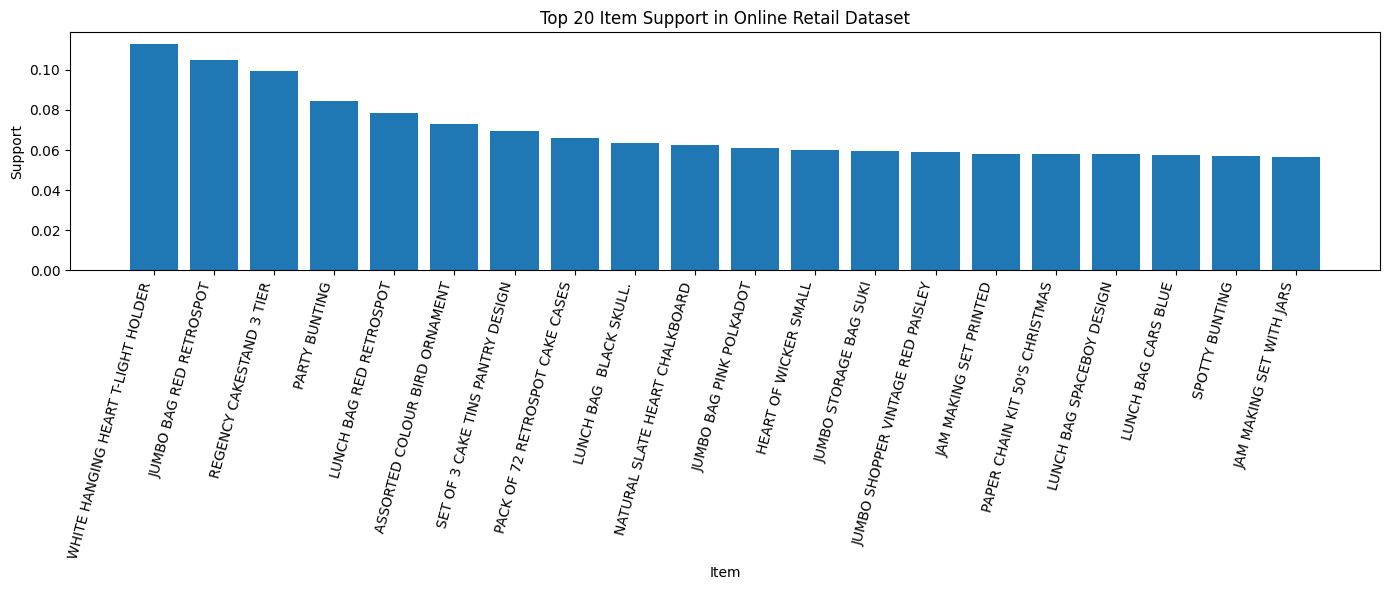

In [17]:
# ============================================================
# 17. 상위 20개 상품 지지도 시각화
# ============================================================

# 상위 20개 상품을 선택합니다.
top20 = torch_item_freq_df.head(20)

# 그래프 크기를 설정합니다.
plt.figure(figsize=(14, 6))

# 상품명과 support를 막대그래프로 표시합니다.
plt.bar(
    top20["item"],
    top20["support"]
)

# x축 상품명이 겹치지 않도록 회전합니다.
plt.xticks(rotation=75, ha="right")

# 그래프 제목을 지정합니다.
plt.title("Top 20 Item Support in Online Retail Dataset")

# x축 이름을 지정합니다.
plt.xlabel("Item")

# y축 이름을 지정합니다.
plt.ylabel("Support")

# 그래프 요소가 잘리지 않도록 자동 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()

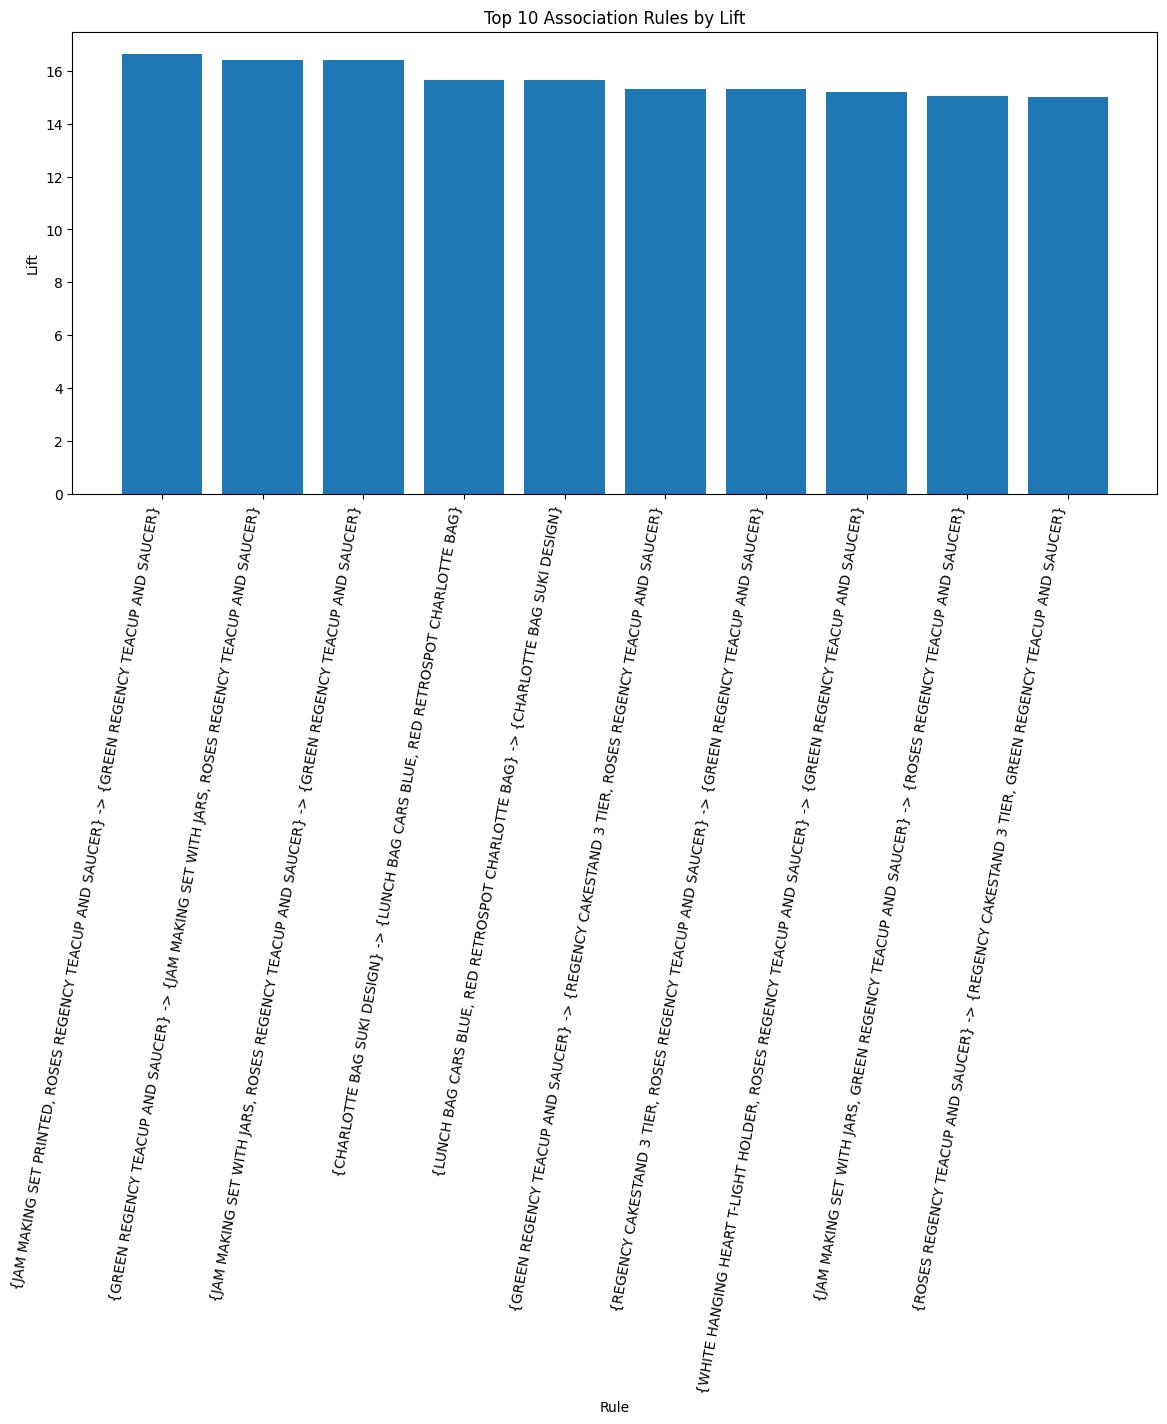

In [18]:
# ============================================================
# 18. 상위 연관규칙 시각화
# ============================================================

# Lift 기준 상위 10개 규칙을 선택합니다.
top_rules = rules_df.sort_values("lift", ascending=False).head(10)

# 그래프 크기를 설정합니다.
plt.figure(figsize=(14, 6))

# 규칙별 Lift 값을 막대그래프로 표시합니다.
plt.bar(
    top_rules["rule"],
    top_rules["lift"]
)

# x축 규칙 문자열이 길기 때문에 회전합니다.
plt.xticks(rotation=80, ha="right")

# 그래프 제목을 지정합니다.
plt.title("Top 10 Association Rules by Lift")

# x축 이름을 지정합니다.
plt.xlabel("Rule")

# y축 이름을 지정합니다.
plt.ylabel("Lift")

# 그래프 요소가 잘리지 않도록 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()

In [19]:
# ============================================================
# 19. 프로젝트 보고서 자동 요약
# ============================================================

# 생성된 규칙이 있을 때만 보고서 요약을 출력합니다.
if len(rules_df) > 0:

    # Support가 가장 높은 규칙을 선택합니다.
    best_support_rule = rules_df.sort_values("support", ascending=False).head(1)

    # Confidence가 가장 높은 규칙을 선택합니다.
    best_confidence_rule = rules_df.sort_values("confidence", ascending=False).head(1)

    # Lift가 가장 높은 규칙을 선택합니다.
    best_lift_rule = rules_df.sort_values("lift", ascending=False).head(1)

    # 분석 요약 정보를 출력합니다.
    print("===== Online Retail 연관분석 프로젝트 요약 =====")
    print("사용 데이터셋: UCI Online Retail Dataset")
    print("전체 거래 수:", len(transactions))
    print("전체 원본 상품 수:", basket_source["Description"].nunique())
    print("실습 사용 상품 수:", num_items)
    print("가장 많이 판매된 상품:", torch_item_freq_df.iloc[0]["item"])
    print("생성된 빈발 아이템셋 수:", len(frequent_itemsets))
    print("생성된 연관규칙 수:", len(rules_df))

    # 최고 Support 규칙을 출력합니다.
    print("\n[최고 Support 규칙]")
    display(best_support_rule[["rule", "support", "confidence", "lift"]])

    # 최고 Confidence 규칙을 출력합니다.
    print("\n[최고 Confidence 규칙]")
    display(best_confidence_rule[["rule", "support", "confidence", "lift"]])

    # 최고 Lift 규칙을 출력합니다.
    print("\n[최고 Lift 규칙]")
    display(best_lift_rule[["rule", "support", "confidence", "lift"]])

else:
    # 규칙이 없는 경우 기준값을 낮추라는 안내를 출력합니다.
    print("현재 MIN_SUPPORT 또는 MIN_CONFIDENCE 조건에서 생성된 규칙이 없습니다.")
    print("MIN_SUPPORT 또는 MIN_CONFIDENCE 값을 낮춰 다시 실행해 보세요.")

===== Online Retail 연관분석 프로젝트 요약 =====
사용 데이터셋: UCI Online Retail Dataset
전체 거래 수: 19960
전체 원본 상품 수: 4015
실습 사용 상품 수: 60
가장 많이 판매된 상품: WHITE HANGING HEART T-LIGHT HOLDER
생성된 빈발 아이템셋 수: 537
생성된 연관규칙 수: 1006

[최고 Support 규칙]


,rule,support,confidence,lift
616,{JUMBO BAG RED RETROSPOT} -> {JUMBO BAG PINK P...,0.041333,0.394926,6.471855



[최고 Confidence 규칙]


,rule,support,confidence,lift
0,"{JAM MAKING SET PRINTED, ROSES REGENCY TEACUP ...",0.01012,0.845188,16.653463



[최고 Lift 규칙]


,rule,support,confidence,lift
0,"{JAM MAKING SET PRINTED, ROSES REGENCY TEACUP ...",0.01012,0.845188,16.653463


# 모범답안 정리

## 1. 사용한 데이터셋 설명

UCI Online Retail Dataset은 2010년 12월 1일부터 2011년 12월 9일까지 영국 기반 온라인 소매업체에서 발생한 실제 거래 데이터이다. 각 행은 하나의 상품 구매 내역이며, InvoiceNo를 기준으로 하나의 장바구니 거래를 구성할 수 있다.

## 2. 전체 거래 수

전처리 후 `len(transactions)` 값으로 확인한다. 취소 거래, 수량 오류, 가격 오류, 상품명 오류를 제거했기 때문에 원본보다 거래 수가 줄어들 수 있다.

## 3. 전체 상품 수

전처리 후 `basket_source["Description"].nunique()` 값으로 확인한다.

## 4. 가장 많이 판매된 상품

`torch_item_freq_df.iloc[0]["item"]` 값으로 확인한다.

## 5. 생성된 규칙 수

`len(rules_df)` 값으로 확인한다.

## 6. 최고 Support 규칙

`rules_df.sort_values("support", ascending=False).head(1)` 로 확인한다. Support가 높다는 것은 전체 거래에서 해당 규칙이 자주 나타난다는 의미이다.

## 7. 최고 Confidence 규칙

`rules_df.sort_values("confidence", ascending=False).head(1)` 로 확인한다. Confidence가 높다는 것은 조건 상품을 구매했을 때 결과 상품도 구매할 확률이 높다는 의미이다.

## 8. 최고 Lift 규칙

`rules_df.sort_values("lift", ascending=False).head(1)` 로 확인한다. Lift가 높다는 것은 두 상품의 관계가 우연이 아니라 실제 연관성이 강할 가능성이 높다는 의미이다.

## 9. 추천 시스템 결과

`recommend("상품명")` 함수를 실행하여 특정 상품을 구매한 고객에게 함께 추천할 수 있는 상품을 확인한다.

## 10. 비즈니스 활용 방안

연관규칙 분석 결과는 온라인 쇼핑몰 추천 상품, 함께 구매하기 기능, 묶음 할인, 장바구니 쿠폰, 재고 관리, 상품 진열 전략에 활용할 수 있다.